Data Sensor Lontar.xlsx (BLT1)

File ini berisi data sensor real-time (5 menit-an) dari unit **BLT1** sepanjang tahun 2025 — parameter Boiler & Turbine (capacity, coal flow, temperature, vibration, dll). 

In [1]:
import sys
print(sys.executable)

c:\Users\DELL\Downloads\KP KP KP\venv\Scripts\python.exe


In [2]:
import pandas as pd
import matplotlib.pyplot as plt                                                                                                                                                                                                                                                                                                                                                                     

FILE_PATH = r"C:\Users\DELL\Downloads\KP KP KP\Lontar.xlsx"

Load & cleaning

File Excel-nya punya format non-standar: 2 baris pertama cuma metadata rentang tanggal, baris ke-3 baru header nama tag sensor, kolom pertama gak kepakai.

In [3]:
raw = pd.read_excel(FILE_PATH, sheet_name=0, header=None, engine="openpyxl")

# Baris index ke-2 (baris ke-3 di Excel) berisi nama tag sensor, mulai kolom C
tag_names = raw.iloc[2, 2:].tolist()
columns = ["col_unused", "timestamp"] + tag_names

df = raw.iloc[3:].copy()
df.columns = columns
df = df.drop(columns=["col_unused"]).reset_index(drop=True)

df["timestamp"] = pd.to_datetime(df["timestamp"])
print(df.shape)
df.head()

(104833, 30)


,timestamp,BLT1.Generator Gross Capacity,BLT1_MVARNETT.REAL,BLT1.Generator Net Capacity,BLT1.Boiler.Total Air Flow,BLT1_COALFLOW.REAL,BLT1.CEMS O2,BLT1.Generator.H2 Inlet Temperature,BLT1.Generator.H2 Pressure,BLT1.Generator.H2 Purity,...,BLT1.Turbine.Bearing 2X Vibration,BLT1.Turbine.Bearing 2Y Vibration,BLT1.Turbine.Bearing 3X Vibration,BLT1.Turbine.Bearing 3Y Vibration,BLT1.Turbine.Bearing 4X Vibration,BLT1.Turbine.Bearing 4Y Vibration,BLT1.Turbine.Bearing 5X Vibration,BLT1.Turbine.Bearing 5Y Vibration,BLT1.Turbine.Bearing 6X Vibration,BLT1.Turbine.Bearing 6Y Vibration
0,2025-01-01 00:00:00,227.573334,-25.250427,Tag not found,1211.471558,163.204941,8.693614,31.995829,290.541229,101.71875,...,56.05677,Tag not found,129.406296,Bad,86.697235,16.586004,72.90435,42.394451,34.664017,30.402626
1,2025-01-01 00:05:00,229.666443,-24.85601,Tag not found,1187.021362,162.164536,9.330313,31.942894,290.658813,101.71875,...,54.972195,Tag not found,129.375351,Bad,86.582481,15.837571,72.500549,42.169514,34.327763,30.498005
2,2025-01-01 00:10:00,229.185593,-25.790701,NaN,1186.49939,163.298737,8.569043,31.928299,290.740204,101.71875,...,54.658535,NaN,130.271851,Bad,87.202873,16.726437,72.513344,42.220798,34.496754,30.310341
3,2025-01-01 00:15:00,229.184052,-25.442646,NaN,1201.388184,162.433212,8.784296,31.89735,290.818329,101.71875,...,54.559254,NaN,129.763214,Bad,87.369926,16.878868,72.886681,41.884499,34.446442,30.457983
4,2025-01-01 00:20:00,225.909332,-25.231731,NaN,1207.335449,161.982849,8.64783,31.849125,290.914124,101.71875,...,53.406464,NaN,129.326157,Bad,86.711937,16.725355,72.585495,41.808975,34.496586,30.387321


Bersihkan Nilai Non-Numerik

Beberapa sel isinya `"Tag not found"` atau `"Bad"` (indikasi sensor error/data quality issue) — ini otomatis jadi `NaN` begitu dikonversi ke numerik dengan `errors="coerce"`.

In [4]:
sensor_cols = [c for c in df.columns if c != "timestamp"]

for col in sensor_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("timestamp").set_index("timestamp")
df.head()

,BLT1.Generator Gross Capacity,BLT1_MVARNETT.REAL,BLT1.Generator Net Capacity,BLT1.Boiler.Total Air Flow,BLT1_COALFLOW.REAL,BLT1.CEMS O2,BLT1.Generator.H2 Inlet Temperature,BLT1.Generator.H2 Pressure,BLT1.Generator.H2 Purity,BLT1.Turbine.Bearing 1 Left Temperature,...,BLT1.Turbine.Bearing 2X Vibration,BLT1.Turbine.Bearing 2Y Vibration,BLT1.Turbine.Bearing 3X Vibration,BLT1.Turbine.Bearing 3Y Vibration,BLT1.Turbine.Bearing 4X Vibration,BLT1.Turbine.Bearing 4Y Vibration,BLT1.Turbine.Bearing 5X Vibration,BLT1.Turbine.Bearing 5Y Vibration,BLT1.Turbine.Bearing 6X Vibration,BLT1.Turbine.Bearing 6Y Vibration
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,227.573334,-25.250427,NaN,1211.471558,163.204941,8.693614,31.995829,290.541229,101.71875,72.591835,...,56.056770,NaN,129.406296,NaN,86.697235,16.586004,72.904350,42.394451,34.664017,30.402626
2025-01-01 00:05:00,229.666443,-24.856010,NaN,1187.021362,162.164536,9.330313,31.942894,290.658813,101.71875,72.553299,...,54.972195,NaN,129.375351,NaN,86.582481,15.837571,72.500549,42.169514,34.327763,30.498005
2025-01-01 00:10:00,229.185593,-25.790701,NaN,1186.499390,163.298737,8.569043,31.928299,290.740204,101.71875,72.664902,...,54.658535,NaN,130.271851,NaN,87.202873,16.726437,72.513344,42.220798,34.496754,30.310341
2025-01-01 00:15:00,229.184052,-25.442646,NaN,1201.388184,162.433212,8.784296,31.897350,290.818329,101.71875,72.607773,...,54.559254,NaN,129.763214,NaN,87.369926,16.878868,72.886681,41.884499,34.446442,30.457983
2025-01-01 00:20:00,225.909332,-25.231731,NaN,1207.335449,161.982849,8.647830,31.849125,290.914124,101.71875,72.596893,...,53.406464,NaN,129.326157,NaN,86.711937,16.725355,72.585495,41.808975,34.496586,30.387321


Cek Kualitas Data (Missing Value per Sensor)

In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct)

# Sensor dengan data hilang > 90% biasanya berarti tag itu memang tidak aktif/terpasang
fully_missing = missing_pct[missing_pct > 90].index.tolist()
print("\nSensor yang datanya nyaris/sepenuhnya kosong:", fully_missing)

 BLT1.Generator Net Capacity                100.000000
BLT1.Turbine.Bearing 2Y Vibration           100.000000
BLT1.Turbine.Bearing 3Y Vibration            37.963237
BLT1.CEMS O2                                  4.789522
BLT1.Turbine.Bearing 2X Vibration             1.800960
BLT1.Turbine.Bearing 3X Vibration             1.624488
BLT1.Generator.H2 Purity                      1.614949
BLT1.Generator.H2 Inlet Temperature           1.613996
BLT1.Generator.H2 Pressure                    1.613996
BLT1_COALFLOW.REAL                            1.613996
BLT1.Boiler.Total Air Flow                    1.613996
BLT1.Generator Gross Capacity                 1.613996
BLT1_MVARNETT.REAL                            1.613996
BLT1.Turbine.Bearing 2 Right Temperature      1.613996
BLT1.Turbine.Bearing 2 Left Temperature       1.613996
BLT1.Turbine.Bearing 1 Right Temperature      1.613996
BLT1.Turbine.Bearing 1 Left Temperature       1.613996
BLT1.Turbine.Bearing 4 Right Temperature      1.613996
BLT1.Turbi

Statistik Ringkas & Visualisasi Contoh Sensor

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BLT1.Generator Gross Capacity,103141.0,245.684539,65.753651,-2.008908,231.883469,268.153473,285.996155,318.139709
BLT1_MVARNETT.REAL,103141.0,2.734636,21.992706,-80.575493,-11.974022,-0.376878,16.810419,80.232727
BLT1.Generator Net Capacity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BLT1.Boiler.Total Air Flow,103141.0,1226.090361,203.767383,53.662086,1242.716553,1273.010254,1299.786377,1482.507935
BLT1_COALFLOW.REAL,103141.0,179.240599,44.885956,-0.644052,175.038849,192.785370,202.926163,255.751328
BLT1.CEMS O2,99812.0,7.201037,4.065945,-0.124677,4.784853,6.145474,7.985384,23.727678
BLT1.Generator.H2 Inlet Temperature,103141.0,32.769023,1.808418,27.137217,31.386179,32.546196,34.180626,37.834122
BLT1.Generator.H2 Pressure,103141.0,288.446065,4.252670,268.697815,285.123627,288.550323,291.868317,303.231079
BLT1.Generator.H2 Purity,103140.0,101.489991,0.724330,98.955231,101.718750,101.718750,101.718750,101.718750
BLT1.Turbine.Bearing 1 Left Temperature,103141.0,72.045979,7.847738,31.167645,73.503166,73.709229,73.884888,75.324211


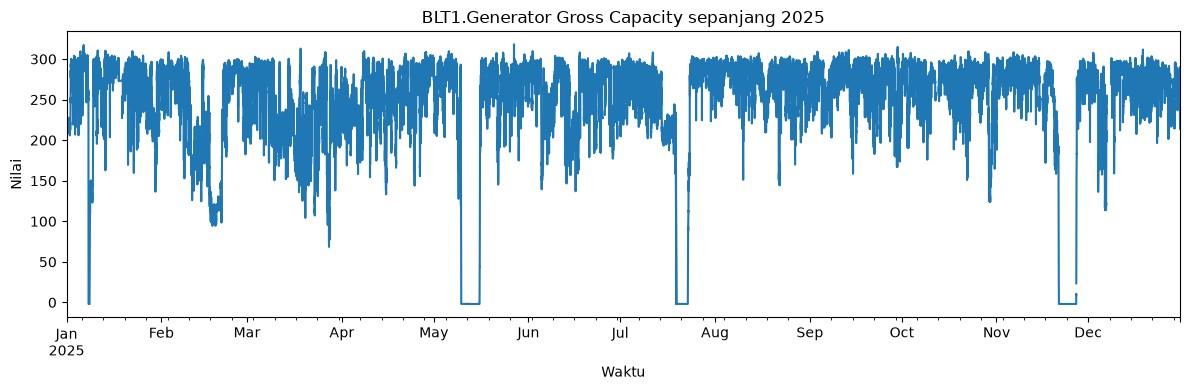

In [7]:
sample_col = "BLT1.Generator Gross Capacity"

plt.figure(figsize=(12, 4))
df[sample_col].plot()
plt.title(f"{sample_col} sepanjang 2025")
plt.xlabel("Waktu")
plt.ylabel("Nilai")
plt.tight_layout()
plt.show()

Simpan Data Bersih

In [8]:
df.to_csv("lontar_clean.csv")
print("Tersimpan sebagai lontar_clean.csv")

Tersimpan sebagai lontar_clean.csv


Catatan Penting

- Kolom yang datanya hilang hampir 100% (misal `Generator Net Capacity`, beberapa `Bearing Vibration`) kemungkinan tag sensornya memang tidak aktif/tidak terpasang di unit ini choose: di-drop atau diimputasi.
- Data ini bersifat numerik time-series jadi case yang cocok untuk data ini adalah predictive maintenance / anomaly detection / forecasting (Random Forest, XGBoost regressor, Isolation Forest)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FILE_PATH = r"C:\Users\DELL\Downloads\KP KP KP\lontar_clean.csv"

df = pd.read_csv(FILE_PATH, index_col=0, parse_dates=True)
df = df.sort_index()
print(df.shape)
df.head()

(104833, 29)


,BLT1.Generator Gross Capacity,BLT1_MVARNETT.REAL,BLT1.Generator Net Capacity,BLT1.Boiler.Total Air Flow,BLT1_COALFLOW.REAL,BLT1.CEMS O2,BLT1.Generator.H2 Inlet Temperature,BLT1.Generator.H2 Pressure,BLT1.Generator.H2 Purity,BLT1.Turbine.Bearing 1 Left Temperature,...,BLT1.Turbine.Bearing 2X Vibration,BLT1.Turbine.Bearing 2Y Vibration,BLT1.Turbine.Bearing 3X Vibration,BLT1.Turbine.Bearing 3Y Vibration,BLT1.Turbine.Bearing 4X Vibration,BLT1.Turbine.Bearing 4Y Vibration,BLT1.Turbine.Bearing 5X Vibration,BLT1.Turbine.Bearing 5Y Vibration,BLT1.Turbine.Bearing 6X Vibration,BLT1.Turbine.Bearing 6Y Vibration
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,227.573334,-25.250427,NaN,1211.471558,163.204941,8.693614,31.995829,290.541229,101.71875,72.591835,...,56.056770,NaN,129.406296,NaN,86.697235,16.586004,72.904350,42.394451,34.664017,30.402626
2025-01-01 00:05:00,229.666443,-24.856010,NaN,1187.021362,162.164536,9.330313,31.942894,290.658813,101.71875,72.553299,...,54.972195,NaN,129.375351,NaN,86.582481,15.837571,72.500549,42.169514,34.327763,30.498005
2025-01-01 00:10:00,229.185593,-25.790701,NaN,1186.499390,163.298737,8.569043,31.928299,290.740204,101.71875,72.664902,...,54.658535,NaN,130.271851,NaN,87.202873,16.726437,72.513344,42.220798,34.496754,30.310341
2025-01-01 00:15:00,229.184052,-25.442646,NaN,1201.388184,162.433212,8.784296,31.897350,290.818329,101.71875,72.607773,...,54.559254,NaN,129.763214,NaN,87.369926,16.878868,72.886681,41.884499,34.446442,30.457983
2025-01-01 00:20:00,225.909332,-25.231731,NaN,1207.335449,161.982849,8.647830,31.849125,290.914124,101.71875,72.596893,...,53.406464,NaN,129.326157,NaN,86.711937,16.725355,72.585495,41.808975,34.496586,30.387321


Korelasi Antar Sensor

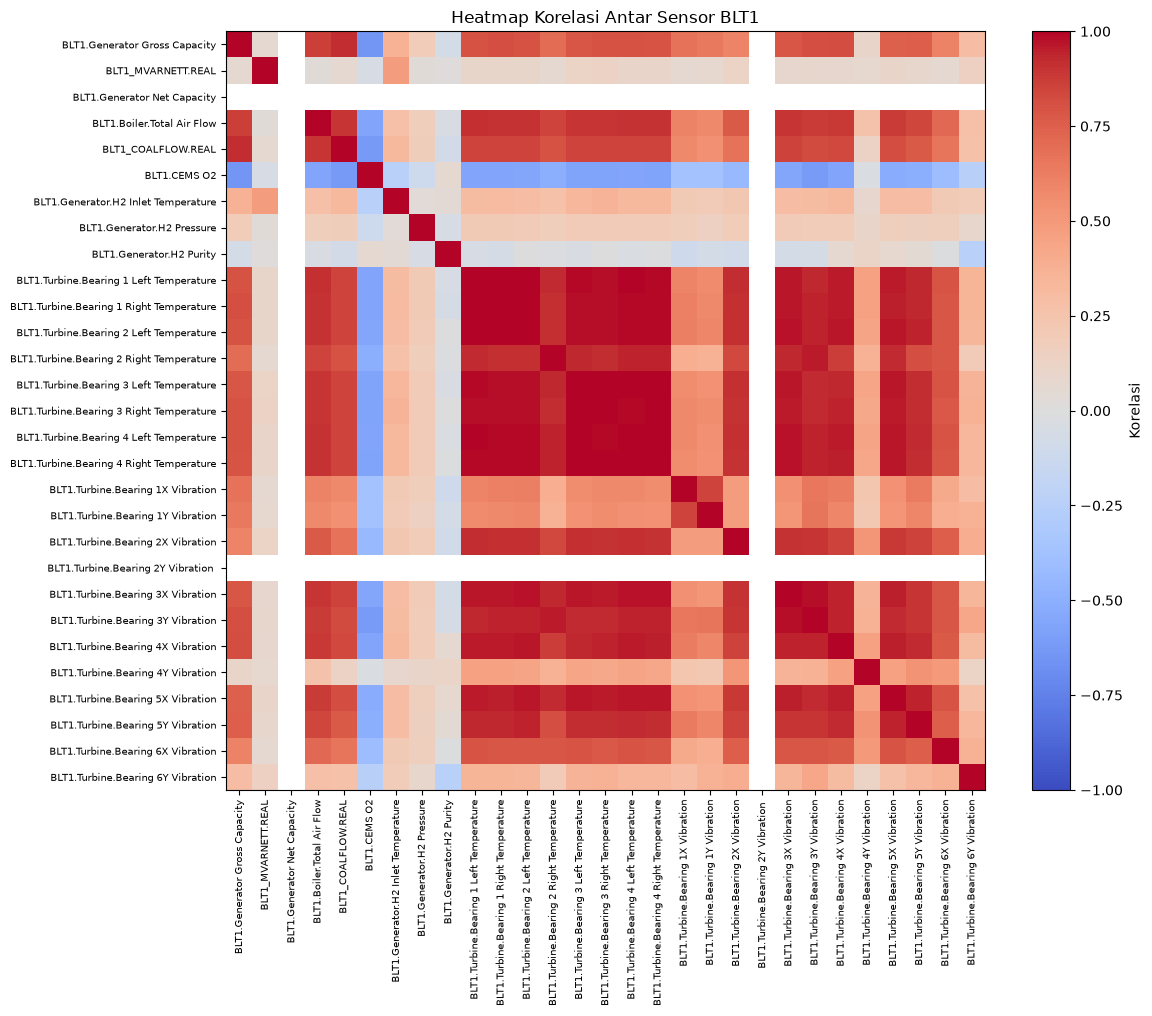

In [10]:
corr = df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Korelasi")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)
plt.title("Heatmap Korelasi Antar Sensor BLT1")
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import plotly.graph_objects as go

corr = df.corr()

# Sembunyiin segitiga atas biar gak duplikat/mirror
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_masked = corr.mask(mask)

fig = go.Figure(data=go.Heatmap(
    z=corr_masked.values,
    x=corr_masked.columns,
    y=corr_masked.columns,
    colorscale="RdBu_r",
    zmin=-1, zmax=1,
    text=np.round(corr_masked.values, 2),
    texttemplate="%{text}",
    textfont={"size": 8},
    hoverongaps=False,
    colorbar=dict(title="Korelasi")
))

fig.update_layout(
    title="Heatmap Korelasi Antar Sensor BLT1 (Interaktif)",
    xaxis=dict(tickangle=90),
    width=1000,
    height=900
)
fig.show()

ModuleNotFoundError: No module named 'plotly'

In [ ]:
# Lihat pasangan sensor dengan korelasi tertinggi (selain diri sendiri)
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 0.999].sort_values(ascending=False)
corr_pairs.head(15)

BLT1.Turbine.Bearing 4 Left Temperature   BLT1.Turbine.Bearing 4 Right Temperature    0.998072
BLT1.Turbine.Bearing 4 Right Temperature  BLT1.Turbine.Bearing 4 Left Temperature     0.998072
BLT1.Turbine.Bearing 1 Left Temperature   BLT1.Turbine.Bearing 1 Right Temperature    0.997963
BLT1.Turbine.Bearing 1 Right Temperature  BLT1.Turbine.Bearing 1 Left Temperature     0.997963
BLT1.Turbine.Bearing 3 Left Temperature   BLT1.Turbine.Bearing 3 Right Temperature    0.995930
BLT1.Turbine.Bearing 3 Right Temperature  BLT1.Turbine.Bearing 3 Left Temperature     0.995930
BLT1.Turbine.Bearing 4 Right Temperature  BLT1.Turbine.Bearing 3 Left Temperature     0.995616
BLT1.Turbine.Bearing 3 Left Temperature   BLT1.Turbine.Bearing 4 Right Temperature    0.995616
                                          BLT1.Turbine.Bearing 4 Left Temperature     0.995325
BLT1.Turbine.Bearing 4 Left Temperature   BLT1.Turbine.Bearing 3 Left Temperature     0.995325
                                          BLT1.Tur

Visualisasi Multi-Sensor (Dinormalisasi)

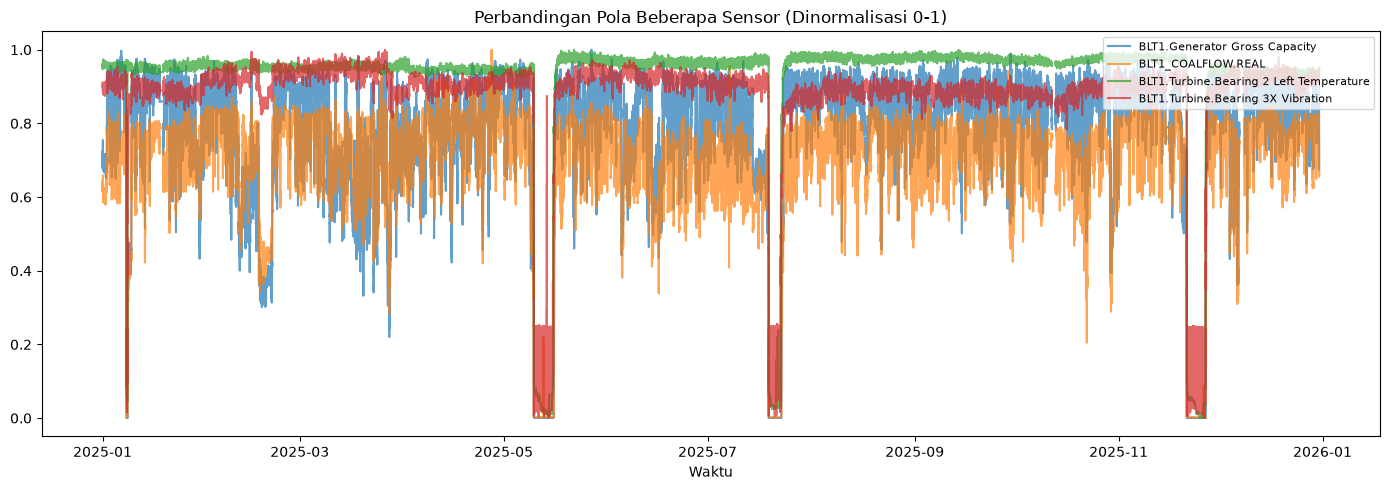

In [ ]:
cols_to_plot = [
    "BLT1.Generator Gross Capacity",
    "BLT1_COALFLOW.REAL",
    "BLT1.Turbine.Bearing 2 Left Temperature",
    "BLT1.Turbine.Bearing 3X Vibration",
]

# Normalisasi 0-1 biar skalanya sebanding waktu diplot bareng
normalized = (df[cols_to_plot] - df[cols_to_plot].min()) / (df[cols_to_plot].max() - df[cols_to_plot].min())

plt.figure(figsize=(14, 5))
for col in cols_to_plot:
    plt.plot(normalized.index, normalized[col], label=col, alpha=0.7)
plt.legend(fontsize=8, loc="upper right")
plt.title("Perbandingan Pola Beberapa Sensor (Dinormalisasi 0-1)")
plt.xlabel("Waktu")
plt.tight_layout()
plt.show()

Forecasting 

Sebagai contoh pipeline, kita coba forecast `BLT1.Turbine.Bearing 2 Left Temperature`(bearing dengan suhu rata-rata tertinggi, jadi relevan untuk dipantau). Target: prediksi suhu **1 jam ke depan** (12 langkah x 5 menit) berdasarkan pola historisnya.

Kenapa gak prediksi 5 menit ke depan aja? Karena di data sensor real-time, nilai t+1 itu hampir selalu mirip banget sama nilai t (autokorelasi sangat tinggi) — jadi terlalu gampang buat dianggap "prediksi" yang bermakna. Horizon 1 jam lebih relevan untuk kebutuhan early-warning yang sebenarnya.

In [ ]:
TARGET_COL = "BLT1.Turbine.Bearing 2 Left Temperature"
HORIZON = 12  # 12 x 5 menit = 1 jam ke depan

data = df[[TARGET_COL]].copy().rename(columns={TARGET_COL: "y"})

# Feature engineering: lag value & rolling statistics
for lag in [1, 2, 3, 6, 12, 24]:
    data[f"lag_{lag}"] = data["y"].shift(lag)
data["roll_mean_6"] = data["y"].shift(1).rolling(6).mean()
data["roll_std_6"] = data["y"].shift(1).rolling(6).std()
data["roll_mean_24"] = data["y"].shift(1).rolling(24).mean()
data["hour"] = data.index.hour
data["dayofweek"] = data.index.dayofweek

# Target: nilai HORIZON langkah ke depan
data["target_future"] = data["y"].shift(-HORIZON)
data = data.dropna()

print(data.shape)
data.head()

(99361, 13)


,y,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,roll_mean_6,roll_std_6,roll_mean_24,hour,dayofweek,target_future
timestamp,,,,,,,,,,,,,
2025-01-01 02:00:00,93.850441,93.874672,93.864899,93.770821,93.742630,93.631523,94.374298,93.816456,0.053833,93.776892,2,2,94.197220
2025-01-01 02:05:00,93.935455,93.850441,93.874672,93.864899,93.846725,93.768486,93.884117,93.834424,0.040639,93.755064,2,2,93.982536
2025-01-01 02:10:00,94.108406,93.935455,93.850441,93.874672,93.798988,93.745155,93.821457,93.849213,0.058312,93.757203,2,2,93.759880
2025-01-01 02:15:00,94.281357,94.108406,93.935455,93.850441,93.770821,93.696045,93.926262,93.900782,0.114633,93.769160,2,2,93.590668
2025-01-01 02:20:00,94.368896,94.281357,94.108406,93.935455,93.864899,93.562393,93.826447,93.985872,0.173326,93.783955,2,2,94.350975


In [ ]:
# Split berdasarkan waktu (BUKAN random split, karena ini time series)
split_idx = int(len(data) * 0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

print("Periode train:", train.index.min(), "-", train.index.max())
print("Periode test :", test.index.min(), "-", test.index.max())

feature_cols = [c for c in data.columns if c != "target_future"]
X_train, y_train = train[feature_cols], train["target_future"]
X_test, y_test = test[feature_cols], test["target_future"]

Periode train: 2025-01-01 02:00:00 - 2025-10-17 02:00:00
Periode test : 2025-10-17 02:05:00 - 2025-12-30 23:00:00


In [ ]:
model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 0.4470
RMSE : 1.9027
R2   : 0.9865


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

for col in df.columns:
    fig.add_trace(
        go.Scatter(x=df.index, y=df[col], name=col, visible=False)
    )

if len(fig.data) > 0:
    fig.data[0].visible = True

buttons = []
for i, col in enumerate(df.columns):
    visibility = [False] * len(fig.data)
    visibility[i] = True

    buttons.append(dict(
        label=col,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Tren Visualisasi: {col}"}]
    ))

fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    title=f"Tren Visualisasi: {df.columns[0]}",
    xaxis_title="Timestamp",
    yaxis_title="Nilai Sensor",
    template="plotly_white"
)

fig.update_xaxes(rangeslider_visible=True)
fig.show()